# Модели кластеризации на примере обработки изображений японских иероглифов

Требования для сдачи лабораторной работы:
1. Использовать набор данных стандарта MNIST
2. Анализ датасета
3. Анализ каждого класса по отдельности


## Скачивание и загрузка датасета Kuzushiji-MNIST

In [ ]:
# Установка библиотеки openml
%pip install openml

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 13.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 11.9 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 5.3 MB/s  0:00:06m0:00:0100:01
Using cached pycparser-3.0-py3-none-any.whl (48 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 3.6 MB/s  0:00:00 eta 0:00:01
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11769 sha256=a6d51682145ada3914b3ac532b98653b064511030020398131961cd2d66825b1
  Stored in directory: /Users/yambu/Library/Caches/pip/wheels/0f/0d/22/0b7a6ecc989eedde58f06a84063f88bcc93e5346cb4dccb045
Successfully built liac-arff
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15/15 [openml]13/15 [minio]-learn]

[notice] A new 

In [34]:
# Импорт библиотек
from dotenv import load_dotenv
import os

import pandas as pd
from scipy.io import arff
import openml
import matplotlib.pyplot as plt

In [3]:
load_dotenv()  # Загружаем переменные окружения из .env файла

True

In [ ]:
# Загрузка датасета через по названию датасета
openml_api_key = os.getenv("OPENML_API_KEY")
openml.config.apikey = openml_api_key

df = openml.datasets.get_dataset("Kuzushiji-MNIST")
df

OpenML Dataset
Name.........: Kuzushiji-MNIST
Version......: 1
Format.......: arff
Upload Date..: 2019-07-23 11:27:57
Licence......: CC BY-SA 4.0
Download URL.: https://openml.org/data/v1/download/21388379/Kuzushiji-MNIST.arff
OpenML URL...: https://www.openml.org/d/41982
# of features: None

In [ ]:
# Загрузка датасета из файла
df_arff = arff.loadarff("dataset.arff")
df = pd.DataFrame(df_arff[0])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 785 entries, pixel-0000 to class
dtypes: float64(784), object(1)
memory usage: 419.2+ MB


In [15]:
df.head(5)

,pixel-0000,pixel-0001,pixel-0002,pixel-0003,pixel-0004,pixel-0005,pixel-0006,pixel-0007,pixel-0008,pixel-0009,...,pixel-0775,pixel-0776,pixel-0777,pixel-0778,pixel-0779,pixel-0780,pixel-0781,pixel-0782,pixel-0783,class
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,255.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'8'
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'7'
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'0'
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0,164.0,...,64.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'1'
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,b'4'


## Изучение датасета

In [26]:
# число классов, размер изображений, количество объектов...
print(f"Число классов: {df['class'].nunique()}")
print(f"Размер изображений: {((df.shape[1] - 1) ** 0.5)}x{((df.shape[1] - 1) ** 0.5)} пикселей")
print(f"Количество объектов: {len(df)}")
print(f"Распределение классов: {df['class'].value_counts()}")

Число классов: 10
Размер изображений: 28.0x28.0 пикселей
Количество объектов: 70000
Распределение классов: class
b'8'    7000
b'7'    7000
b'0'    7000
b'1'    7000
b'4'    7000
b'2'    7000
b'5'    7000
b'6'    7000
b'9'    7000
b'3'    7000
Name: count, dtype: int64


In [27]:
df.describe()

,pixel-0000,pixel-0001,pixel-0002,pixel-0003,pixel-0004,pixel-0005,pixel-0006,pixel-0007,pixel-0008,pixel-0009,...,pixel-0774,pixel-0775,pixel-0776,pixel-0777,pixel-0778,pixel-0779,pixel-0780,pixel-0781,pixel-0782,pixel-0783
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,...,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,0.301243,0.741543,1.249814,2.179300,3.693329,5.875200,8.773643,12.551114,16.945986,21.871629,...,35.132743,25.873400,18.033886,12.375786,8.735043,6.299857,4.600371,3.092871,1.610871,0.505957
std,6.156516,10.437733,13.743910,18.550983,24.260307,30.348452,36.944220,44.025184,50.908111,57.488900,...,75.074359,65.537368,55.269795,45.881976,38.601974,32.606155,27.867166,22.711429,15.786300,7.623220
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000


In [32]:
print(f"Один пиксель изображения кодируется {df.iloc[:, :-1].max().max().astype(int) + 1} уровнями серого")

Один пиксель изображения кодируется 256 уровнями серого


KeyError: -1

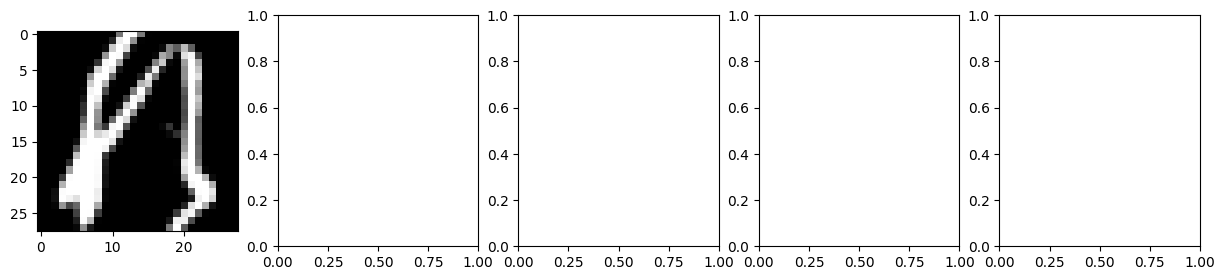

In [ ]:
# Визуализация изображений
get_image = lambda row: row[:-1].values.reshape(28, 28).astype(int)
get_label = lambda row: row[-1].decode("utf-8")

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(get_image(df.iloc[i]), cmap="gray")
    ax.set_title(f"Label: {get_label(df.iloc[i])}")
    ax.axis("off")
plt.show()